# Notebook 05: Modeling
Model training, tuning, evaluation.

**Input:** `data/featured/model_ready.csv`

In [1]:
import pandas as pd
import os
import sys

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

from src.modeling import run_training_pipeline, prepare_train_test
from src.visualizations import plot_roc_curves, plot_confusion_matrices, plot_feature_importance

In [2]:
# Run training pipeline
results, best_model, scaler = run_training_pipeline(
    data_path='data/featured/model_ready.csv',
    model_dir='model',
    save_all_models=True
)

Best model (Logistic Regression) saved to model/best_model.pkl
Scaler saved to model/scaler.pkl
Saved Logistic Regression to model/logistic_regression.pkl
Saved Random Forest to model/random_forest.pkl
Saved Gradient Boosting to model/gradient_boosting.pkl


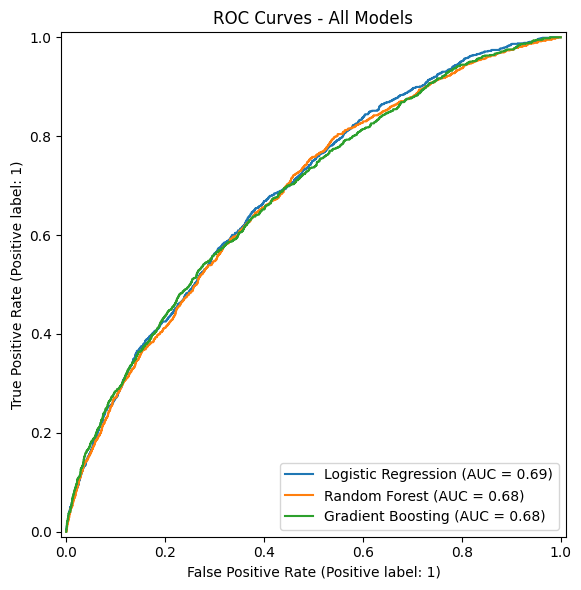

In [3]:
df = pd.read_csv('data/featured/model_ready.csv')
X_train, X_test, y_train, y_test = prepare_train_test(df)

# Plot ROC Curves
plot_roc_curves(results, y_test, save_path='images/eda_charts/roc_comparison.png')

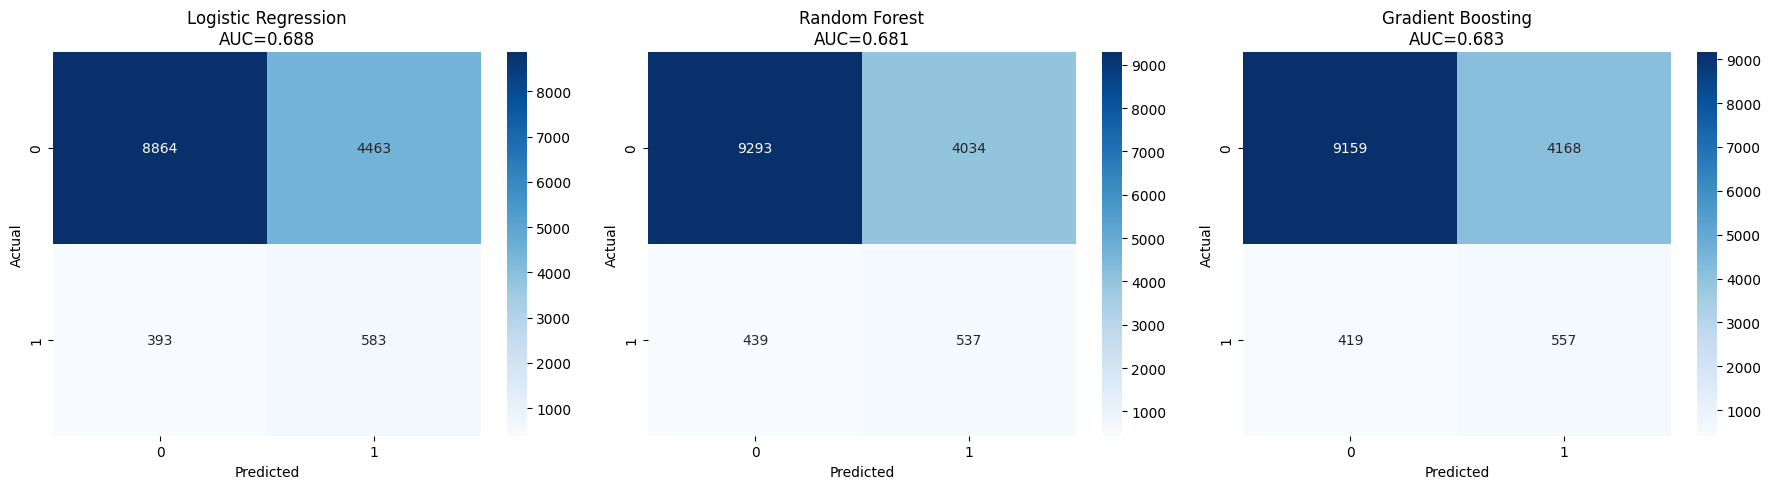

In [4]:
# Plot Confusion Matrices
plot_confusion_matrices(results, y_test, save_path='images/eda_charts/confusion_matrices.png')

In [5]:
# Plot Feature Importance for Best Model (Gradient Boosting)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    plot_feature_importance(importances, top_n=15, save_path='images/eda_charts/feature_importance.png')